# 1. Imports and Data Loading

In [1]:
import math
import os
import torch
import seaborn as sns
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, HistGradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV, train_test_split, RandomizedSearchCV
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report,accuracy_score
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler, QuantileTransformer

This notebook is designed to work on kaggle and locally, therefore the files must be retrieved.

In [2]:
def load_data():
    '''try to load the data from the local directory, if not found, load it from the Kaggle dataset. Output the three dataframes: train, test, and submission.'''
    
    try:
        # check if the data files are in kaggle /kaggle/input/competitions/playground-series-s6e6 directory
        print("Trying to load data from kaggle input directory...")
        train = pd.read_csv('/kaggle/input/competitions/playground-series-s6e6/train.csv')
        test = pd.read_csv('/kaggle/input/competitions/playground-series-s6e6/test.csv')
        submission = pd.read_csv('/kaggle/input/competitions/playground-series-s6e6/sample_submission.csv')
        print("Data loaded successfully from kaggle input directory.")
    except FileNotFoundError:
        print("Data files not found in kaggle input directory. \nTrying to load data from local directory...")
        # Load data from local directory 
        data_dir = os.getcwd()+ '/data/'
        train = pd.read_csv(data_dir + 'train.csv')
        test = pd.read_csv(data_dir + 'test.csv')
        submission = pd.read_csv(data_dir + 'sample_submission.csv') 
        print("Data loaded successfully from local directory.")

    return train, test, submission


train_df, test_df, submission_df = load_data()

# Check GPU availability
if torch.cuda.is_available():
    print(f"GPU detected: {torch.cuda.get_device_name(0)}. Setting global device to 'cuda'.")
    GLOBAL_DEVICE = 'cuda'
else:
    print("No GPU detected. Setting global device to 'cpu'.")
    GLOBAL_DEVICE = 'cpu'


Trying to load data from kaggle input directory...
Data files not found in kaggle input directory. 
Trying to load data from local directory...
Data loaded successfully from local directory.
GPU detected: NVIDIA GeForce RTX 2060. Setting global device to 'cuda'.


# 2. Data Exploration

In [3]:
train_df.describe()

,id,alpha,delta,u,g,r,i,z,redshift
count,577347.00000,577347.000000,577347.000000,577347.000000,577347.000000,577347.000000,577347.000000,577347.000000,577347.000000
mean,288673.00000,181.616673,21.834654,22.441926,21.007273,19.962811,19.378911,19.041136,0.723135
std,166665.86727,96.242941,18.933570,2.018135,1.795426,1.648964,1.580059,1.584365,0.810070
min,0.00000,0.011684,-17.966988,-0.139225,13.535483,12.579407,11.962781,11.682803,-0.009970
25%,144336.50000,132.161499,2.474097,20.977090,19.865005,18.820671,18.306820,17.973192,0.181052
50%,288673.00000,188.681465,21.484412,22.570222,21.467820,20.431153,19.631642,19.188598,0.497525
75%,433009.50000,231.829693,36.988310,23.869103,22.292715,21.164096,20.608191,20.162111,0.881390
max,577346.00000,359.999810,79.158322,28.253263,27.620208,25.254499,27.910853,26.826867,7.010780


In [4]:
train_df.notnull().sum()    

id                   577347
alpha                577347
delta                577347
u                    577347
g                    577347
r                    577347
i                    577347
z                    577347
redshift             577347
spectral_type        577347
galaxy_population    577347
class                577347
dtype: int64

In [5]:
def quality_check(df):
    '''check for missing values, duplicated rows, and data types of each column in the dataframe.
    Parameters:
    df (pandas dataframe): the dataframe to check for quality issues.
    '''
    temp_df = df.copy()

    missing_msg = f"The total number of missing values in the training dataset is: {temp_df.isnull().sum().sum()}"
    print(missing_msg)
    print("-" * len(missing_msg))
    dup_msg = f"The total number of duplicated rows in the training dataset is: {temp_df.duplicated().sum()}"
    print(dup_msg)
    print("-" * len(dup_msg))
    print(f"The data types of each column in the training dataset are:\n{temp_df.dtypes}")
    

quality_check(train_df)

The total number of missing values in the training dataset is: 0
----------------------------------------------------------------
The total number of duplicated rows in the training dataset is: 0
-----------------------------------------------------------------
The data types of each column in the training dataset are:
id                     int64
alpha                float64
delta                float64
u                    float64
g                    float64
r                    float64
i                    float64
z                    float64
redshift             float64
spectral_type            str
galaxy_population        str
class                    str
dtype: object


The class distribution in the target column 'class' is:
class
GALAXY    377480
QSO       117143
STAR       82724
Name: count, dtype: int64


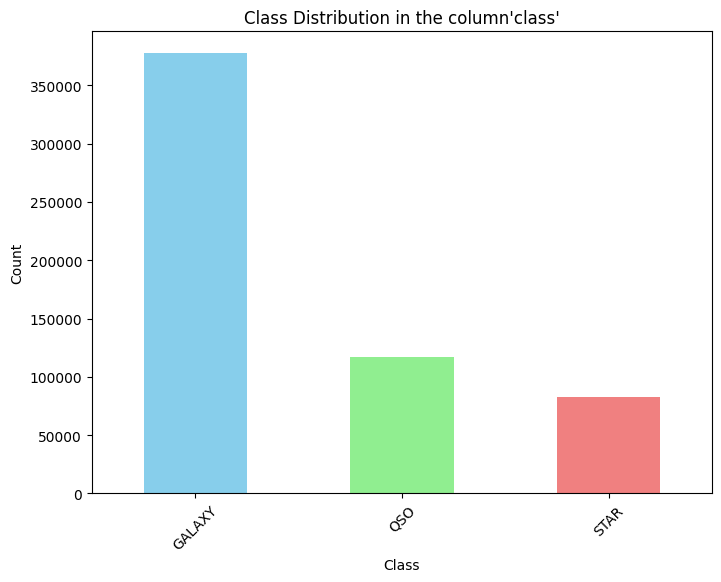

In [6]:
def class_imbalance_check(df, target_col):
    '''Check for class imbalance in the target column of the dataframe.Accepts the dataframe and the name of the targer column as arguments.'''
    class_counts = df[target_col].value_counts()
    print(f"The class distribution in the target column '{target_col}' is:\n{class_counts}")
    #plot the class distribution as a bar chart using matplotlib
    #give the bars different colors
    #
    plt.figure(figsize=(8, 6))
    class_counts.plot(kind='bar', color=['skyblue', 'lightgreen', 'lightcoral', 'gold'])
    plt.title(f"Class Distribution in the column'{target_col}'")
    plt.xlabel("Class")
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.show()

target_column = 'class'
class_imbalance_check(train_df, target_column)

# 3.Data Preprocessing

## 3.1 Categorical feature preprocesssing

The data is prepared for training by dropping unnecessary columns like `id` which will not influence the target class. Furthermore, the target column `class` is mapped to integers for convinience working with models. 
Since `spectral_type` on has 2 unique variables, binary encoding is suitable. In contrast `galaxy_population` has multiple variables and therefore one hot encoding is required to avoid models misinterpreting  the interger representation of the column for varrying magnitudes.  

In [7]:
def drop_id_column(df):
    '''Drop the 'id' column from the dataframe if it exists.'''
    temp_df = df.copy()
    if 'id' in temp_df.columns:
        temp_df = temp_df.drop(columns=['id'])
        print("The 'id' column has been dropped from the dataframe.")
    else:
        print("The 'id' column does not exist in the dataframe.")
    return temp_df

no_id_train_df = drop_id_column(train_df)
no_id_train_df.head()


The 'id' column has been dropped from the dataframe.


,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population,class
0,147.734256,16.959273,25.472123,21.895559,20.357926,19.257113,18.621057,0.408982,M,Red_Sequence,GALAXY
1,127.988677,32.346716,20.778509,19.087062,17.587208,17.226067,16.786433,0.157976,M,Red_Sequence,GALAXY
2,179.792648,35.344843,21.035203,21.079128,21.171840,20.582629,20.557366,2.823770,O/B,Blue_Cloud,QSO
3,225.818295,48.569421,23.305056,21.050736,19.017754,18.365658,17.914952,0.536099,M,Red_Sequence,GALAXY
4,141.836135,19.342852,21.703158,19.471680,18.234449,17.899447,17.616185,0.555761,M,Red_Sequence,GALAXY


In [8]:
def preprocess_categorical_features(df, target_col):
    '''Preprocess the categorical features in the dataframe. 
    This function will re-map the target variable to numerical values using a dictionary mapping GALAXY to 0, QSO to 1 and STAR to 2. 
    It will also  binary encode the galaxy_population column, and apply one-hot encoding to the spectral_type column.'''

    temp_df = df.copy()
    #Re-map the target variable to numerical values using a dictionary mapping GALAXY to 0, QSO to 1 and STAR to 2.
    class_mapping = {'GALAXY': 0, 'QSO': 1, 'STAR': 2}
    temp_df[target_col] = temp_df[target_col].map(class_mapping)

    # Binary encode galaxy_population using a fixed mapping
    galaxy_population_mapping = {'Red_Sequence': 0, 'Blue_Cloud': 1}
    temp_df['galaxy_population'] = temp_df['galaxy_population'].map(galaxy_population_mapping)

    #Applying one-hot encoding to spectral_type column
    temp_df = pd.get_dummies(temp_df, columns=['spectral_type'], drop_first=True, dtype=int)
    return temp_df

target_col = 'class'
preprocessed_categorical_train_df = preprocess_categorical_features(no_id_train_df, target_col)
preprocessed_categorical_train_df.head()

,alpha,delta,u,g,r,i,z,redshift,galaxy_population,class,spectral_type_G/K,spectral_type_M,spectral_type_O/B
0,147.734256,16.959273,25.472123,21.895559,20.357926,19.257113,18.621057,0.408982,0,0,0,1,0
1,127.988677,32.346716,20.778509,19.087062,17.587208,17.226067,16.786433,0.157976,0,0,0,1,0
2,179.792648,35.344843,21.035203,21.079128,21.171840,20.582629,20.557366,2.823770,1,1,0,0,1
3,225.818295,48.569421,23.305056,21.050736,19.017754,18.365658,17.914952,0.536099,0,0,0,1,0
4,141.836135,19.342852,21.703158,19.471680,18.234449,17.899447,17.616185,0.555761,0,0,0,1,0


## 3.2 Numerical feature preprocessing

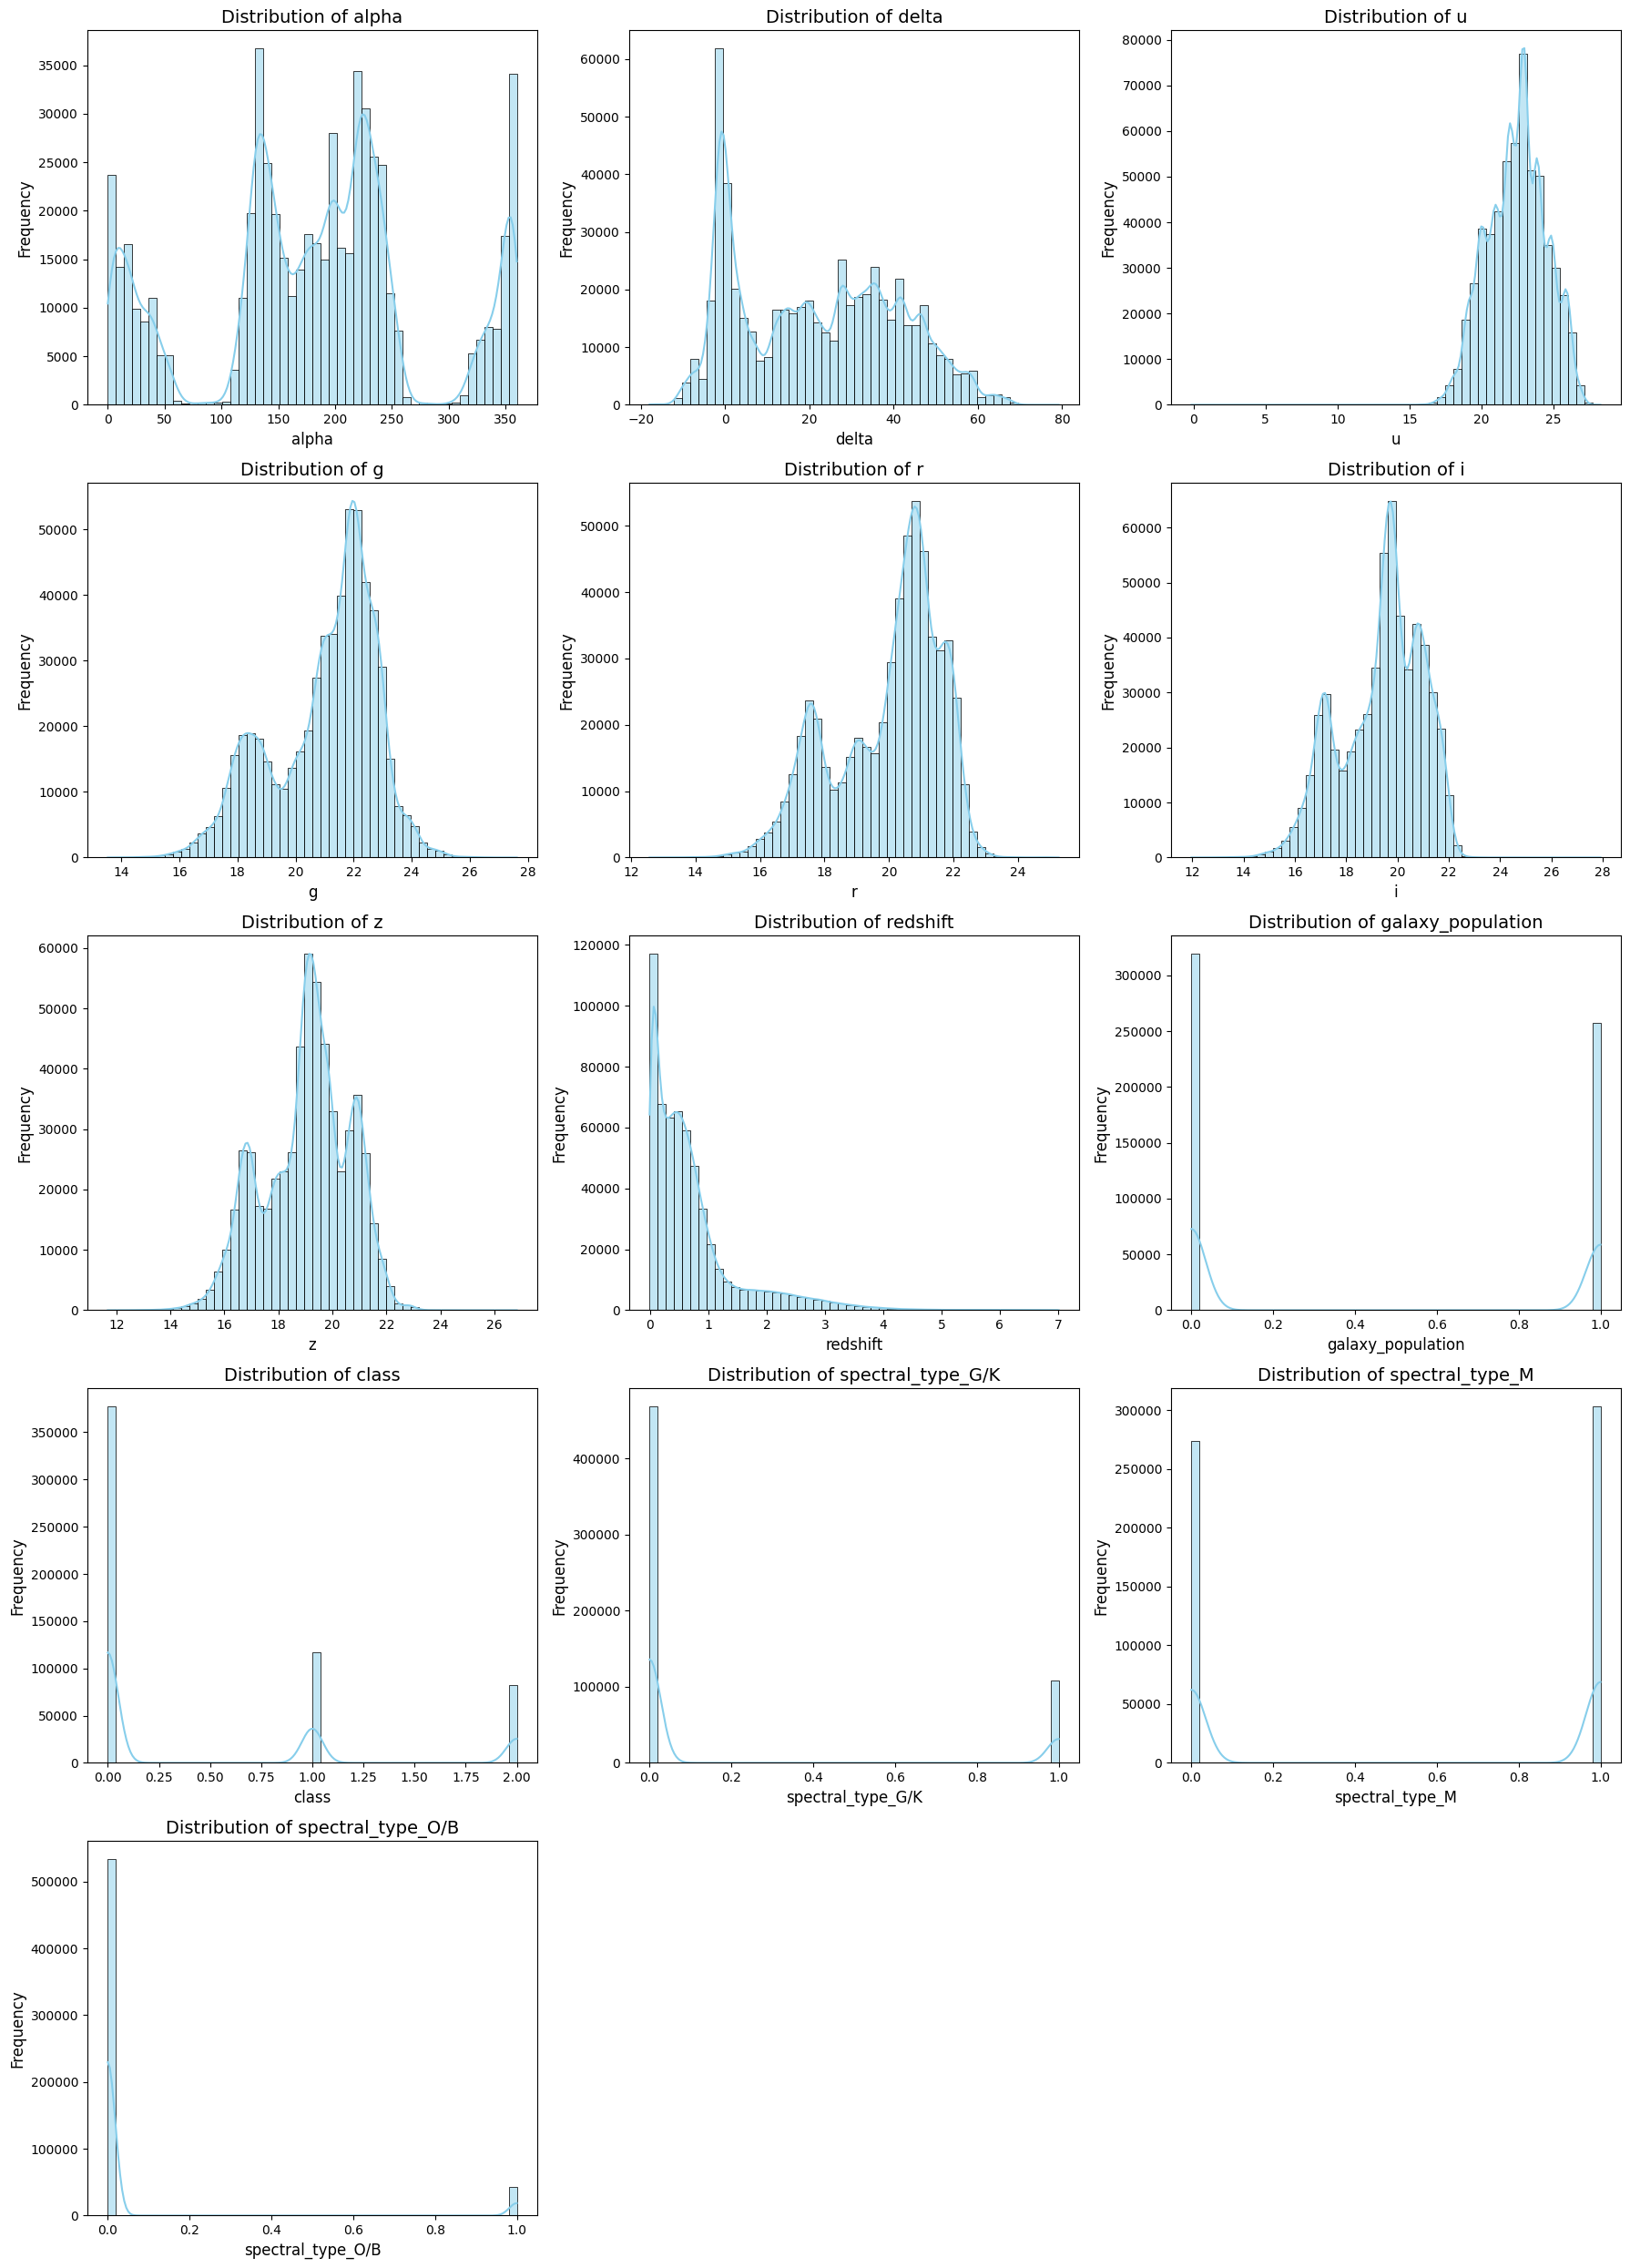

In [9]:
def plot_numerical_distributions(df, bins=50, sample_size=None):
    """
    Plots the distribution of specified numerical columns in a grid.
    
    Parameters:
    - df: pandas DataFrame
    - bins: int, number of histogram bins
    - sample_size: int, optional (randomly sample data for faster plotting on huge datasets)
    """
    temp_df = df.copy()
    numerical_columns = temp_df.select_dtypes(include = ['int64', 'float64']).columns.tolist()
    numerical_columns = temp_df.select_dtypes(include = ['int64', 'float64']).columns.tolist()
    if sample_size and len(temp_df) > sample_size:
        data_to_plot = df.sample(n=sample_size, random_state=42)
    else:
        data_to_plot = temp_df
        
    n_cols = 3
    n_rows = math.ceil(len(numerical_columns) / n_cols)
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
    axes = axes.flatten() # Flatten to 1D array for easy iteration
    
    for i, col in enumerate(numerical_columns):
        # Plot histogram with density line
        sns.histplot(data_to_plot[col].dropna(), kde=True, ax=axes[i], 
                     bins=bins, color='skyblue', edgecolor='black')
        
        axes[i].set_title(f'Distribution of {col}', fontsize=14)
        axes[i].set_xlabel(col, fontsize=12)
        axes[i].set_ylabel('Frequency', fontsize=12)
        
    # Remove any empty subplots if the number of columns isn't a multiple of 3
    for j in range(len(numerical_columns), len(axes)):
        fig.delaxes(axes[j])
        
    plt.tight_layout()
    plt.show()

plot_numerical_distributions(preprocessed_categorical_train_df)

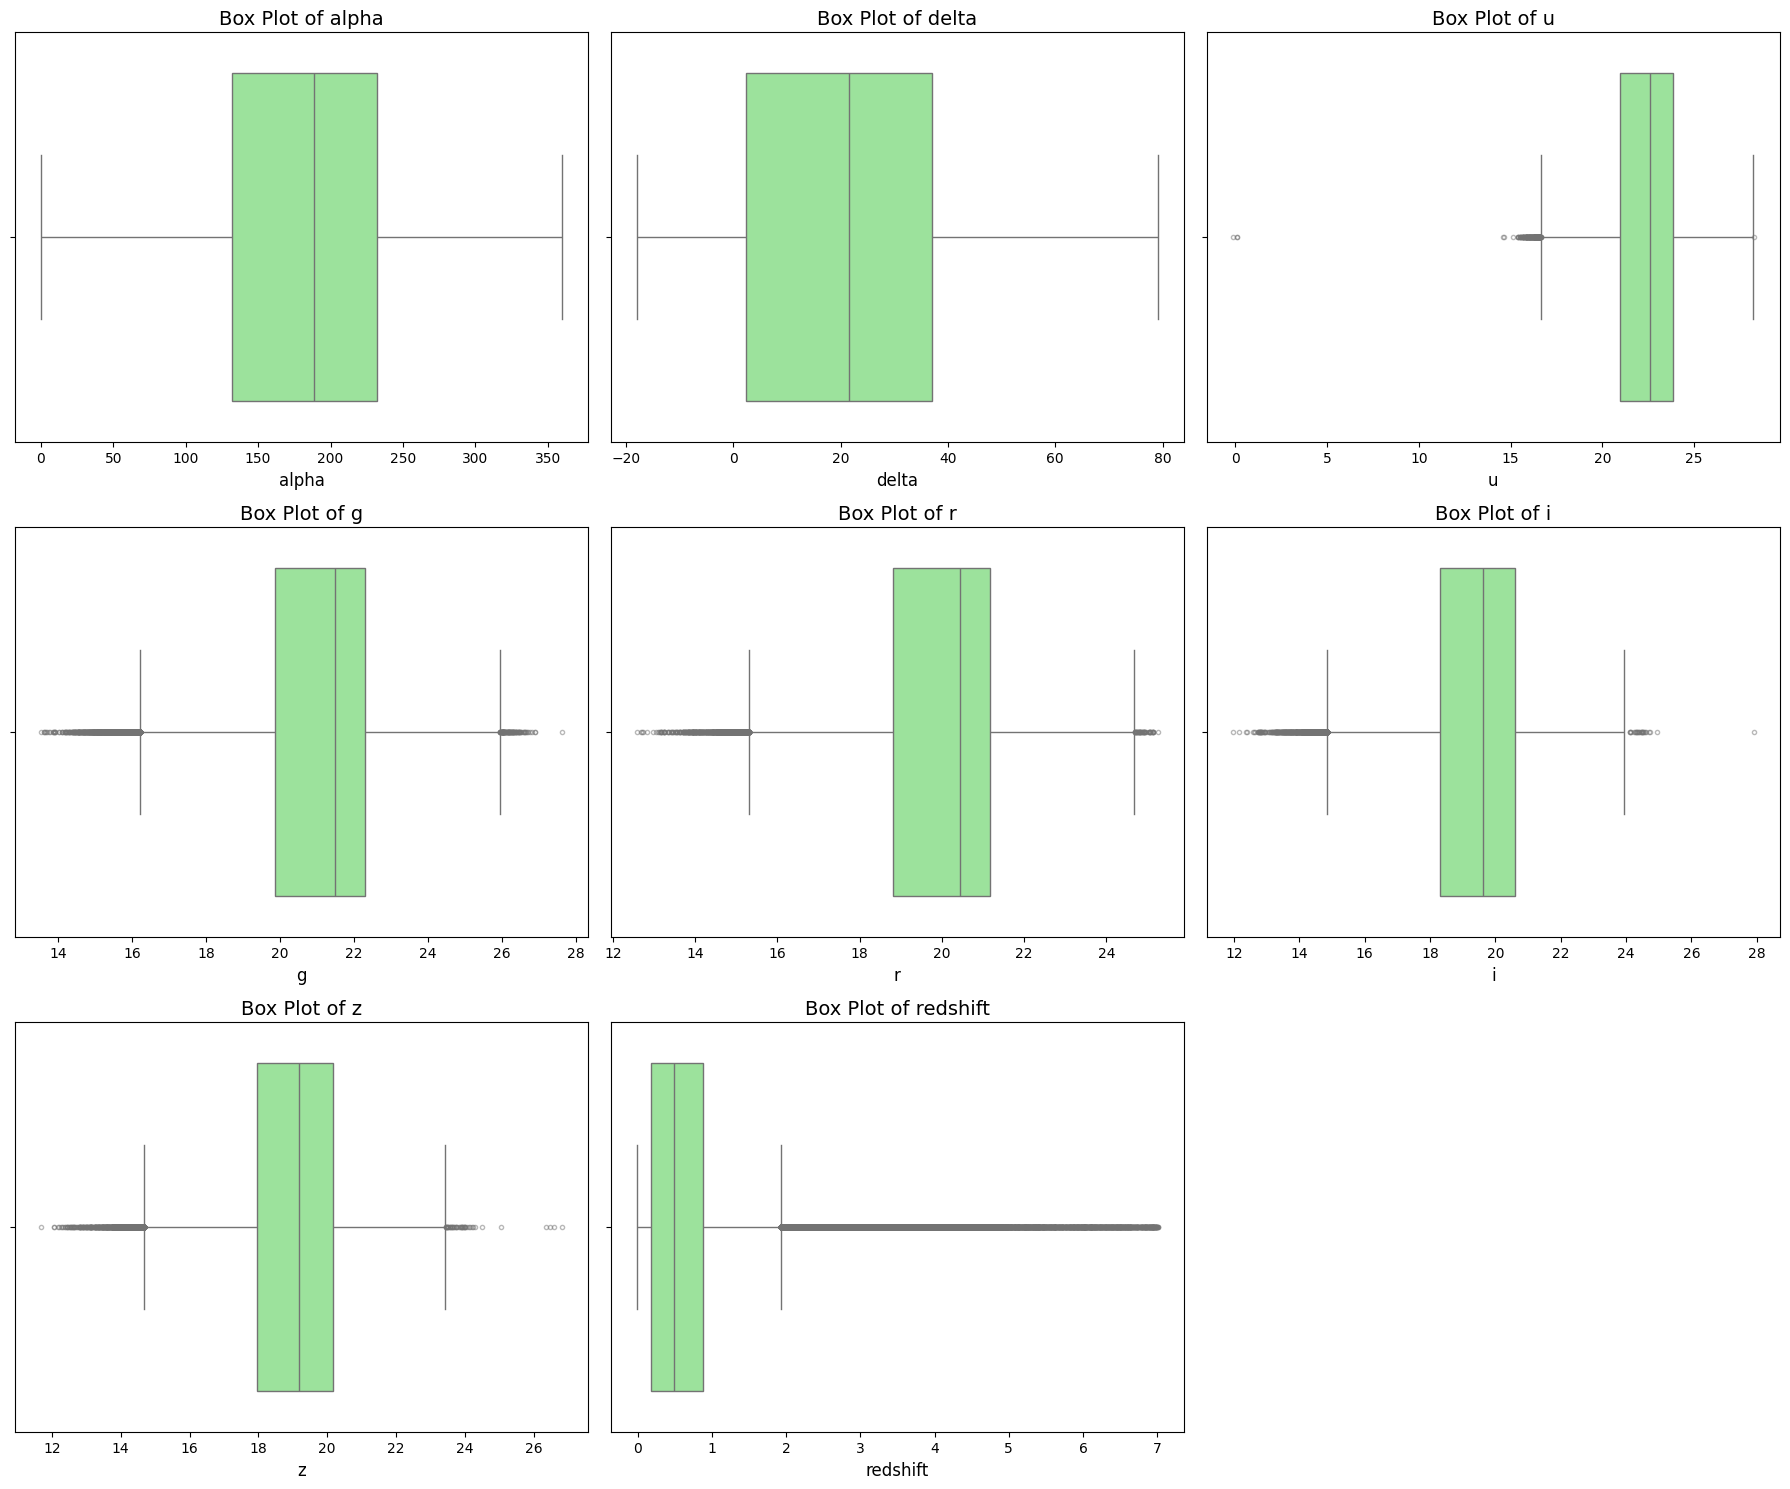

In [10]:
def plot_numerical_boxplots(df, sample_size=None):
    """
    Plots box plots of specified numerical columns in a grid.
    
    Parameters:
    - df: pandas DataFrame
    - sample_size: int, optional (randomly sample data for faster plotting)
    """
    temp_df = df.copy()
    numerical_columns = no_id_train_df.select_dtypes(include = ['int64', 'float64']).columns.tolist()
    if sample_size and len(temp_df) > sample_size:
        data_to_plot = temp_df.sample(n=sample_size, random_state=42)
    else:
        data_to_plot = temp_df
        
    n_cols = 3
    n_rows = math.ceil(len(numerical_columns) / n_cols)
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
    axes = axes.flatten() # Flatten to 1D array for easy iteration
    
    for i, col in enumerate(numerical_columns):
        # Plot boxplot, styling the outlier dots slightly transparent
        sns.boxplot(x=data_to_plot[col].dropna(), ax=axes[i], color='lightgreen', 
                    flierprops=dict(marker='o', markersize=3, alpha=0.5))
        
        axes[i].set_title(f'Box Plot of {col}', fontsize=14)
        axes[i].set_xlabel(col, fontsize=12)
        
    # Remove any empty subplots if the number of columns isn't a multiple of 3
    for j in range(len(numerical_columns), len(axes)):
        fig.delaxes(axes[j])
        
    plt.tight_layout()
    plt.show()

plot_numerical_boxplots(preprocessed_categorical_train_df)

1. Coordinates: `alpha` and `delta`

**Scaler**: MinMaxScaler

**Why**: These are bounded spatial angles (Right Ascension and Declination). MinMaxScaler will compress them into a tight [0, 1] range while perfectly preserving the exact shape of their uniform/slightly skewed distributions. I don't want to standardize these because they don't have a true "center" (mean) in the traditional statistical sense.

2. The "Well-Behaved" Bands: `g`, `r`, and `i`

**Scaler**: StandardScaler

**Why**: As seen in the distributions, these three photometric bands are mostly bell-shaped (normal distributions) with relatively manageable outliers. StandardScaler will center them at a mean of 0 and a standard deviation of 1, which is exactly what Neural Networks and linear models expect.

3. The "Outlier-Heavy" Bands: `u` and `z`

**Scaler**: RobustScaler

**Why**: The box plots showed that u and z have a tight core but extreme outliers stretching far to the edges. If I use a StandardScaler, those massive outliers will skew the mean and standard deviation, crushing the rest of your normal data into a tiny range. RobustScaler ignores the outliers by scaling based on the Median and the Interquartile Range (IQR).

4. The Skewed Outlier: `redshift`

**Scaler**: QuantileTransformer (or RobustScaler)

**Why**: redshift is the trickiest feature. It has a massive spike near 0 and a long tail of extremely important outliers (which represent Quasars). A QuantileTransformer will smooth out this extreme skew by mapping the data to a normal or uniform distribution, preventing the massive 6.0+ outliers from overwhelming distance-based algorithms, while keeping them distinct from the 0.0 values.

In [11]:
def fit_scalers(df):
    '''Fits numerical scalers on the provided dataframe and returns them in a dictionary.'''
    scalers = {
        'minmax': MinMaxScaler().fit(df[['alpha', 'delta']]),
        'standard': StandardScaler().fit(df[['g', 'r', 'i']]),
        'robust': RobustScaler().fit(df[['u', 'z']]),
        'quantile': QuantileTransformer().fit(df[['redshift']])
    }
    return scalers

def transform_numerical_features(df, scalers):
    '''Transforms numerical features using pre-fitted scalers to prevent data leakage.'''
    temp_df = df.copy()
    temp_df[['alpha', 'delta']] = scalers['minmax'].transform(temp_df[['alpha', 'delta']])
    temp_df[['g', 'r', 'i']] = scalers['standard'].transform(temp_df[['g', 'r', 'i']])
    temp_df[['u', 'z']] = scalers['robust'].transform(temp_df[['u', 'z']])
    temp_df[['redshift']] = scalers['quantile'].transform(temp_df[['redshift']])
    return temp_df

# For EDA plotting purposes, we scale the entire dataset here.
# NOTE: To prevent data leakage, we will re-fit scalers strictly on the training split later!
eda_scalers = fit_scalers(preprocessed_categorical_train_df)
preprocessed_numerical_train_df = transform_numerical_features(preprocessed_categorical_train_df, eda_scalers)
preprocessed_numerical_train_df.head()


,alpha,delta,u,g,r,i,z,redshift,galaxy_population,class,spectral_type_G/K,spectral_type_M,spectral_type_O/B
0,0.410354,0.359600,1.003419,0.494750,0.239615,-0.077084,-0.259279,0.438903,0,0,0,1,0
1,0.355503,0.518029,-0.619538,-1.069503,-1.440665,-1.362510,-1.097421,0.235657,0,0,0,1,0
2,0.499408,0.548897,-0.530779,0.040021,0.733207,0.761819,0.625317,0.963578,1,1,0,0,1
3,0.627261,0.685057,0.254091,0.024207,-0.573122,-0.641276,-0.581861,0.538464,0,0,0,1,0
4,0.393970,0.384141,-0.299813,-0.855282,-1.048151,-0.936335,-0.718351,0.552206,0,0,0,1,0


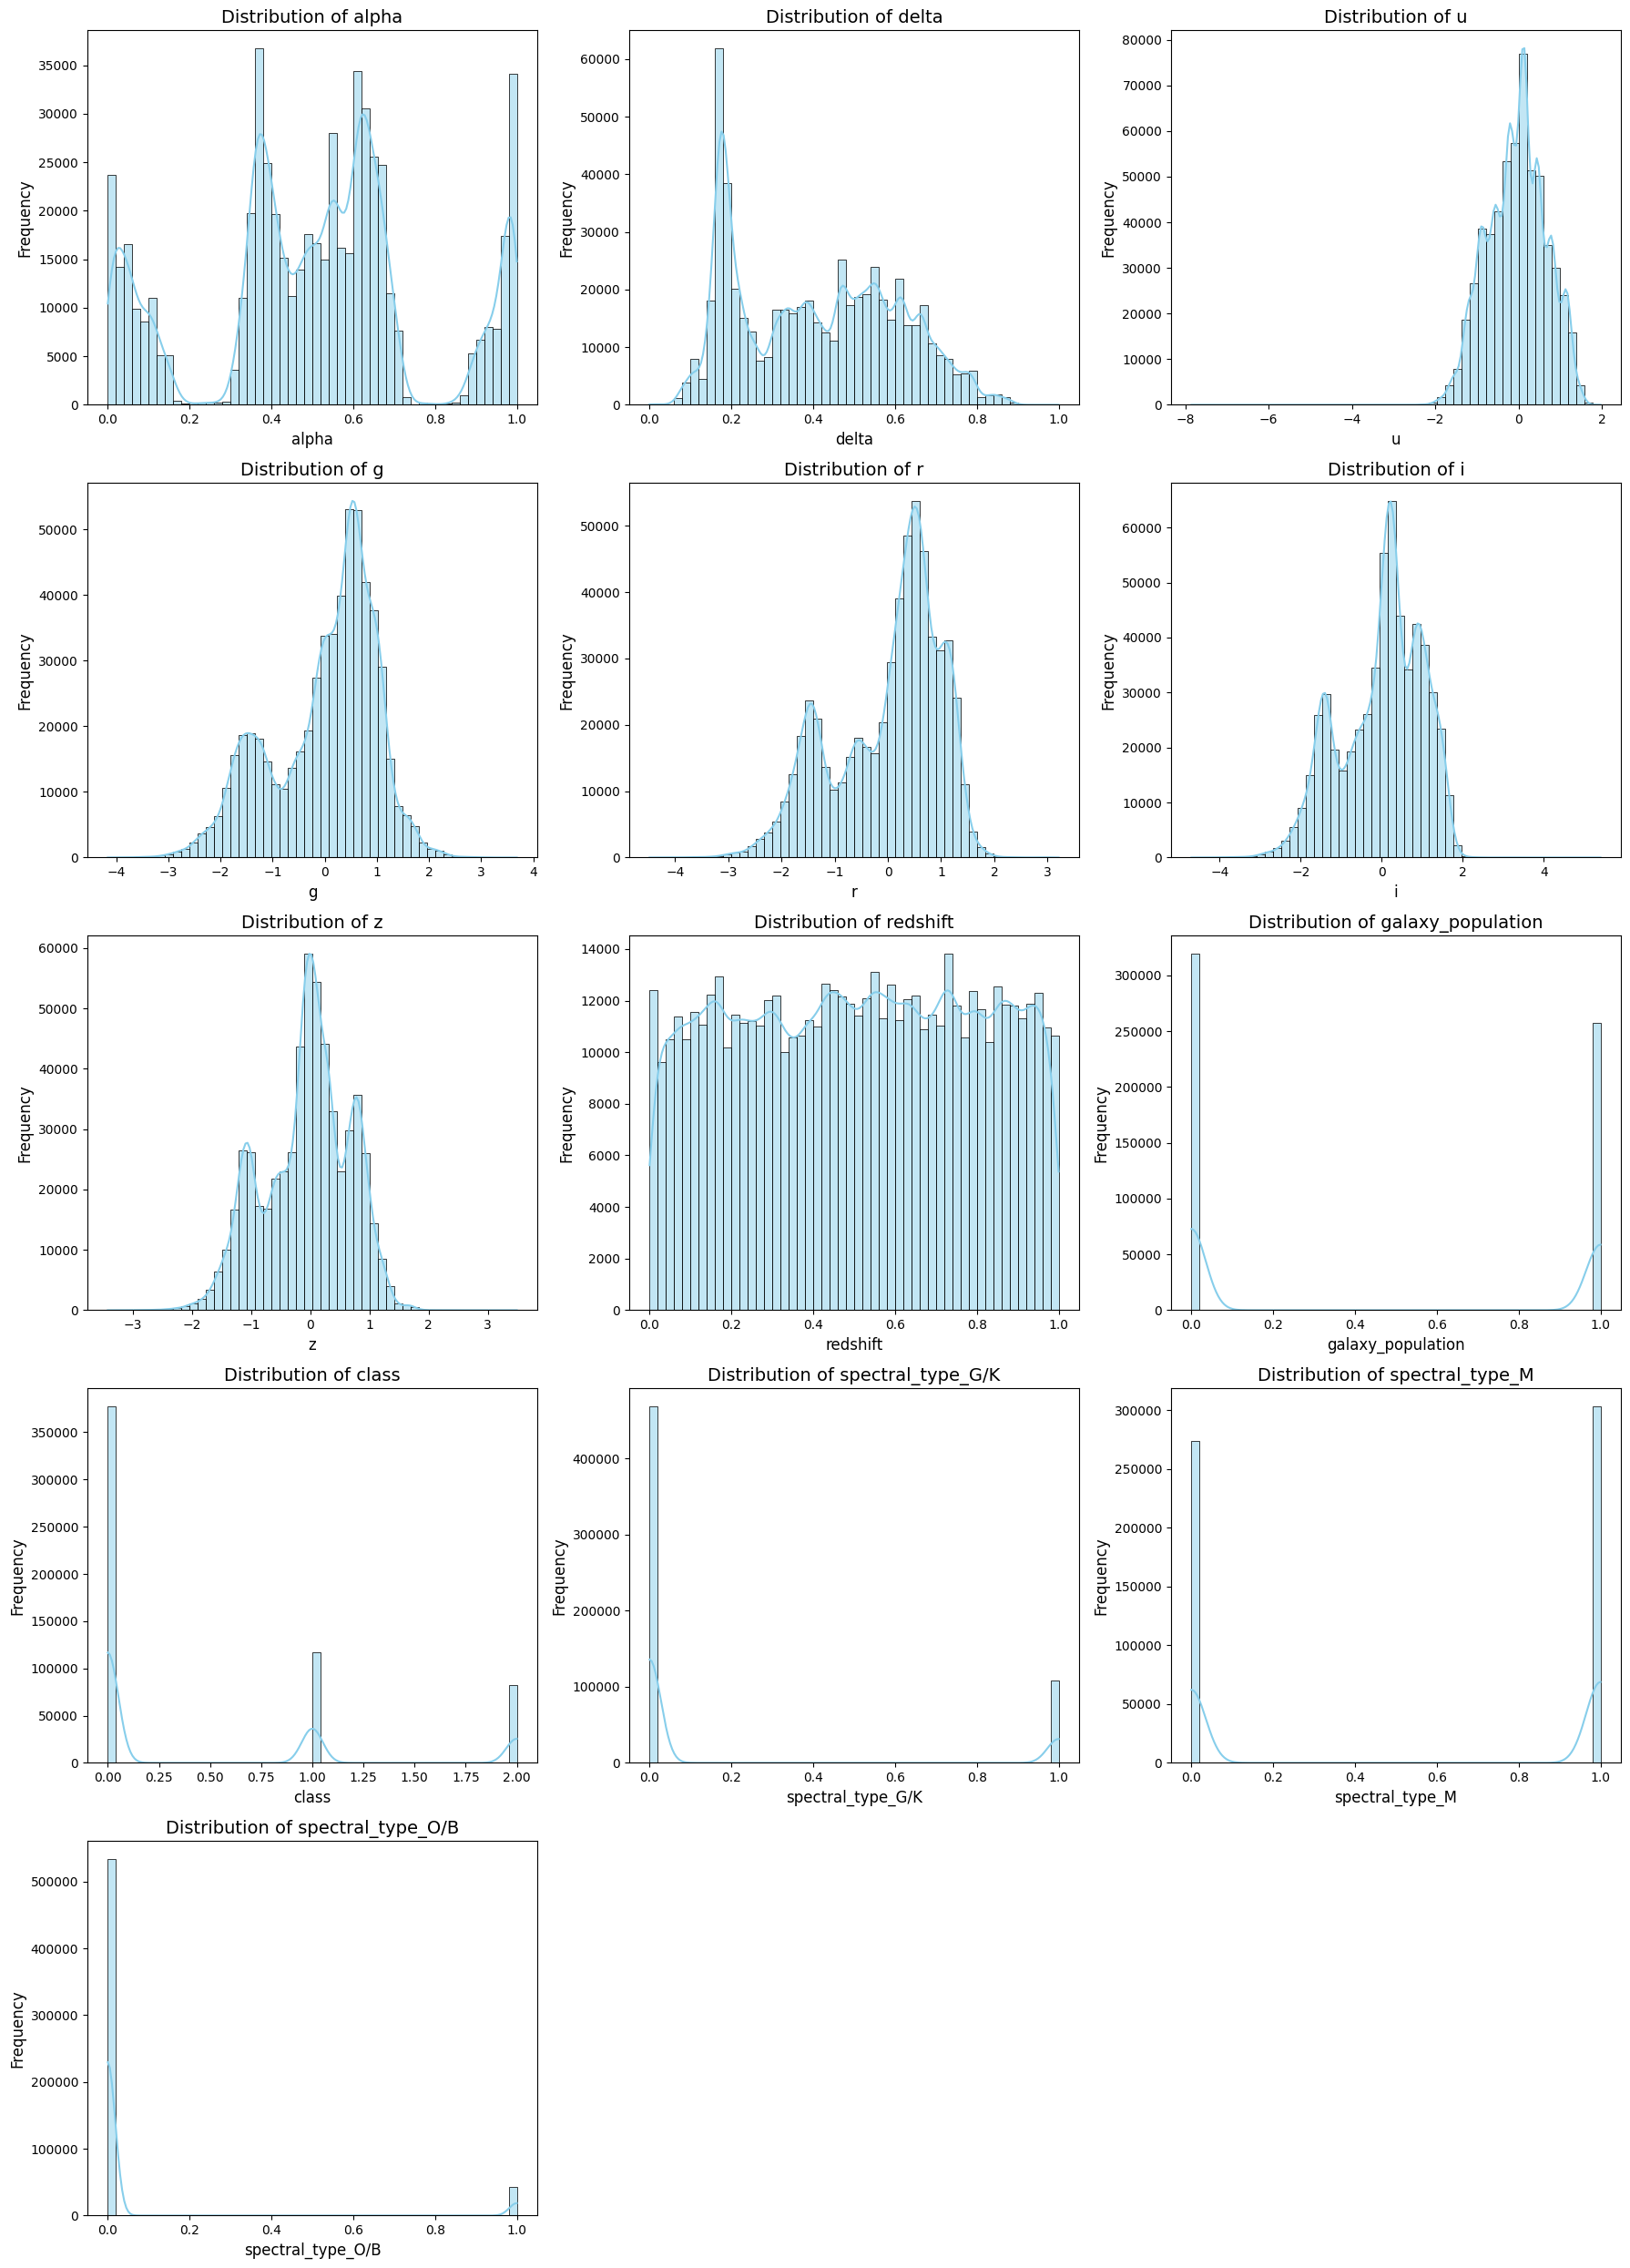

In [12]:
plot_numerical_distributions(preprocessed_numerical_train_df)

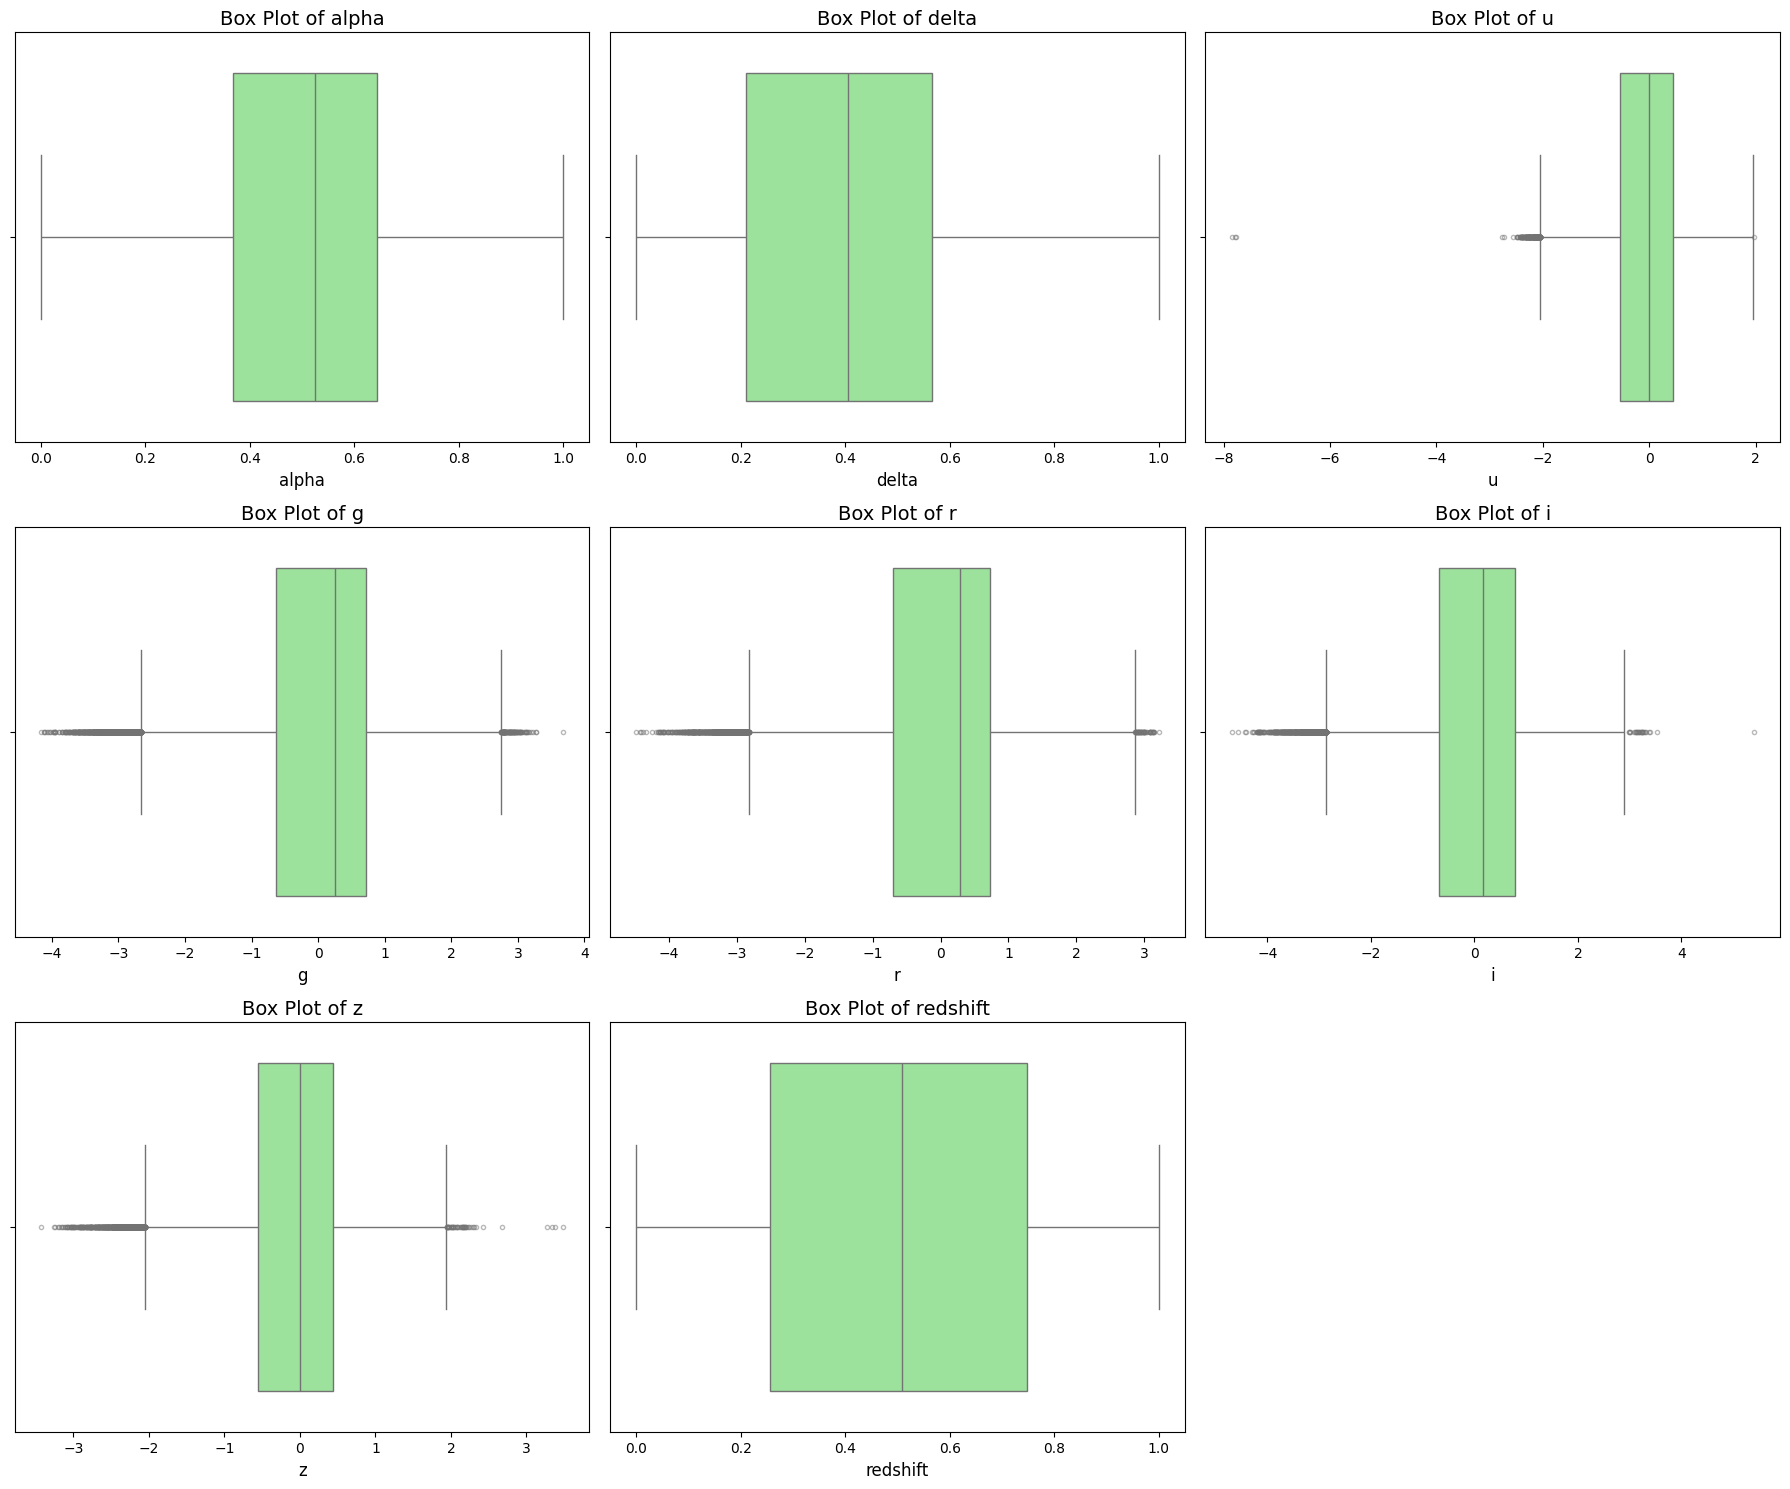

In [13]:
plot_numerical_boxplots(preprocessed_numerical_train_df)

In [14]:
preprocessed_numerical_train_df.head()

,alpha,delta,u,g,r,i,z,redshift,galaxy_population,class,spectral_type_G/K,spectral_type_M,spectral_type_O/B
0,0.410354,0.359600,1.003419,0.494750,0.239615,-0.077084,-0.259279,0.438903,0,0,0,1,0
1,0.355503,0.518029,-0.619538,-1.069503,-1.440665,-1.362510,-1.097421,0.235657,0,0,0,1,0
2,0.499408,0.548897,-0.530779,0.040021,0.733207,0.761819,0.625317,0.963578,1,1,0,0,1
3,0.627261,0.685057,0.254091,0.024207,-0.573122,-0.641276,-0.581861,0.538464,0,0,0,1,0
4,0.393970,0.384141,-0.299813,-0.855282,-1.048151,-0.936335,-0.718351,0.552206,0,0,0,1,0


# 4 Training the model

## 4.1 Base data training
In this iteration I use the preprocessed features. This will allow me to establish a base accuracy score and determine which preprocessing steps will imporve accuracy

In [15]:
def prepare_training_data(df, target_col):
    '''Splits the dataframe into training and testing datasets.'''
    X = df.drop(columns=[target_col])
    y = df[target_col]
    return train_test_split(X, y, test_size=0.2, random_state=42)

In [16]:


def train_and_evaluate_models(models_dict, X_train, X_test, y_train, y_test, prefix=""):
    '''
    Trains multiple models, evaluates them using classification reports, 
    and returns a DataFrame comparing their performance.
    '''
    from sklearn.base import clone
    results = []
    trained_models = {}
    
    for name, model_instance in models_dict.items():
        model_name = f"{prefix}{name}"
        print(f"--- Training {model_name} ---")
        
        current_model = clone(model_instance)
        current_model.fit(X_train, y_train)
        trained_models[model_name] = current_model
        
        # Make predictions
        y_pred = current_model.predict(X_test)
        
        # Evaluate
        acc = accuracy_score(y_test, y_pred)
        report = classification_report(y_test, y_pred, output_dict=True)
        
        print(f"\nClassification Report for {model_name}:")
        print(classification_report(y_test, y_pred))
        print("=" * 60 + "\n")
        
        results.append({
            'Model': model_name,
            'Accuracy': acc,
            'Macro F1-Score': report['macro avg']['f1-score'],
            'Weighted F1-Score': report['weighted avg']['f1-score']
        })
        
    # Create comparison DataFrame
    comparison_df = pd.DataFrame(results).sort_values(by='Accuracy', ascending=False).reset_index(drop=True)
    return comparison_df, trained_models

# 1. Prepare Data
# We split BEFORE scaling to strictly prevent data leakage!
X_train_raw, X_test_raw, y_train, y_test = prepare_training_data(preprocessed_categorical_train_df, 'class')

# Fit scalers ONLY on training data, then transform both train and test sets
training_scalers = fit_scalers(X_train_raw)
X_train = transform_numerical_features(X_train_raw, training_scalers)
X_test = transform_numerical_features(X_test_raw, training_scalers)

# 2. Define Models
models_to_train = {
    'XGBoost': XGBClassifier(n_estimators=200, random_state=42, n_jobs=-1, tree_method='hist', device=GLOBAL_DEVICE),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'Extra Trees': ExtraTreesClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'HistGradientBoosting': HistGradientBoostingClassifier(random_state=42),
    'Neural Network (MLP)': MLPClassifier(random_state=42, max_iter=300),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
}

# 3. Train, Evaluate and Compare
comparison_df, trained_models = train_and_evaluate_models(models_to_train, X_train, X_test, y_train, y_test, prefix="base_")

# Display the comparison table
comparison_df

--- Training base_XGBoost ---


c:\Users\David\.conda\envs\kaggle\Lib\site-packages\xgboost\core.py:751: UserWarning: [22:04:59] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\common\error_msg.cc:62: Falling back to prediction using DMatrix due to mismatched devices. This might lead to higher memory usage and slower performance. XGBoost is running on: cuda:0, while the input data is on: cpu.
Potential solutions:
- Use a data structure that matches the device ordinal in the booster.
- Set the device for booster before call to inplace_predict.

This warning will only be shown once.

  return func(**kwargs)



Classification Report for base_XGBoost:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98     75694
           1       0.97      0.96      0.97     23243
           2       0.93      0.93      0.93     16533

    accuracy                           0.97    115470
   macro avg       0.96      0.96      0.96    115470
weighted avg       0.97      0.97      0.97    115470


--- Training base_Random Forest ---

Classification Report for base_Random Forest:
              precision    recall  f1-score   support

           0       0.97      0.97      0.97     75694
           1       0.96      0.96      0.96     23243
           2       0.91      0.90      0.90     16533

    accuracy                           0.96    115470
   macro avg       0.95      0.95      0.95    115470
weighted avg       0.96      0.96      0.96    115470


--- Training base_Extra Trees ---

Classification Report for base_Extra Trees:
              precision    recall

,Model,Accuracy,Macro F1-Score,Weighted F1-Score
0,base_XGBoost,0.968113,0.956715,0.968105
1,base_HistGradientBoosting,0.963610,0.950210,0.963617
2,base_Random Forest,0.961211,0.947026,0.961175
3,base_Extra Trees,0.958301,0.942213,0.958182
4,base_Neural Network (MLP),0.956725,0.939309,0.956605
5,base_K-Nearest Neighbors,0.945787,0.923979,0.945564


## 4.2 Addressing class imbalance training

As seen earlier the target column is unevenly distributed. There are a couple of ways to balance it. This section will explore them and anaylse their effect on the different models

### 4.2.1 SMOTE Oversampling

In [17]:
def balance_classes(X, y, method='smote'):
    '''
    Balances the class distribution of the dataset.
    
    Parameters:
    - X: pandas DataFrame, feature variables
    - y: pandas Series, target variable
    - method: str, 'smote' for oversampling or 'under' for undersampling
    
    Returns:
    - X_resampled, y_resampled: DataFrames with balanced classes
    '''
    print(f"Original class distribution:\n{y.value_counts()}\n")
    
    if method == 'smote':
        print("Applying SMOTE (Oversampling)...")
        sampler = SMOTE(random_state=42)
    elif method == 'under':
        print("Applying RandomUnderSampler (Undersampling)...")
        sampler = RandomUnderSampler(random_state=42)
    else:
        raise ValueError("Method must be 'smote' or 'under'")
        
    X_resampled, y_resampled = sampler.fit_resample(X, y)
    print(f"\nClass distribution after {method}:\n{y_resampled.value_counts()}")
    
    return X_resampled, y_resampled


In [18]:
# Apply SMOTE to balance the training data
X_train_bal, y_train_bal = balance_classes(X_train, y_train, method='smote')

# Re-evaluate the models using the balanced training data
# We reuse the models_to_train dictionary defined in section 4.1
comparison_df_bal, trained_models_bal = train_and_evaluate_models(
    models_to_train, X_train_bal, X_test, y_train_bal, y_test, prefix="smote_"
)

# Combine all trained models
all_trained_models = {**trained_models, **trained_models_bal}

# Combine all comparison dataframes
all_comparisons_df = pd.concat([comparison_df, comparison_df_bal], ignore_index=True)
all_comparisons_df = all_comparisons_df.sort_values(by='Accuracy', ascending=False).reset_index(drop=True)

# Display the comparison table for the balanced approach
all_comparisons_df


Original class distribution:
class
0    301786
1     93900
2     66191
Name: count, dtype: int64

Applying SMOTE (Oversampling)...

Class distribution after smote:
class
1    301786
0    301786
2    301786
Name: count, dtype: int64
--- Training smote_XGBoost ---

Classification Report for smote_XGBoost:
              precision    recall  f1-score   support

           0       0.99      0.95      0.97     75694
           1       0.95      0.97      0.96     23243
           2       0.86      0.96      0.91     16533

    accuracy                           0.96    115470
   macro avg       0.93      0.96      0.95    115470
weighted avg       0.96      0.96      0.96    115470


--- Training smote_Random Forest ---

Classification Report for smote_Random Forest:
              precision    recall  f1-score   support

           0       0.98      0.95      0.97     75694
           1       0.95      0.97      0.96     23243
           2       0.85      0.94      0.90     16533

    accura

,Model,Accuracy,Macro F1-Score,Weighted F1-Score
0,base_XGBoost,0.968113,0.956715,0.968105
1,base_HistGradientBoosting,0.963610,0.950210,0.963617
2,base_Random Forest,0.961211,0.947026,0.961175
3,smote_XGBoost,0.959565,0.946921,0.960137
4,base_Extra Trees,0.958301,0.942213,0.958182
5,base_Neural Network (MLP),0.956725,0.939309,0.956605
6,smote_Random Forest,0.956127,0.942033,0.956676
7,smote_Extra Trees,0.955183,0.939680,0.955684
8,smote_HistGradientBoosting,0.953486,0.939243,0.954351
9,smote_Neural Network (MLP),0.950039,0.933389,0.950930


**SMOTE Created Noise and Blurred Decision Boundaries**

From the classification reports for Class 2 (STAR):

Base XGBoost: Precision = 0.93, Recall = 0.93
SMOTE XGBoost: Precision = 0.86, Recall = 0.96

SMOTE interpolates between existing points to create new, synthetic data. Because it forced the creation of ~235,000 fake stars to match the galaxy count, it likely generated data points in overlapping regions (the "boundaries" between galaxies and stars). As a result, the model became hyper-sensitive to predicting Class 2 (Recall went up to 0.96), but it started misclassifying a lot of non-stars as stars (Precision plummeted to 0.86).

### 4.2.2 RandomUnderSampler

In [19]:
# Apply RandomUnderSampler to balance the training data
X_train_under, y_train_under = balance_classes(X_train, y_train, method='under')

# Re-evaluate the models using the undersampled training data
comparison_df_under, trained_models_under = train_and_evaluate_models(
    models_to_train, X_train_under, X_test, y_train_under, y_test, prefix="under_"
)

# Combine all trained models
all_trained_models.update(trained_models_under)

# Combine all comparison dataframes
all_comparisons_df = pd.concat([all_comparisons_df, comparison_df_under], ignore_index=True)
all_comparisons_df = all_comparisons_df.sort_values(by='Accuracy', ascending=False).reset_index(drop=True)

# Display the final comparison table including undersampling
all_comparisons_df


Original class distribution:
class
0    301786
1     93900
2     66191
Name: count, dtype: int64

Applying RandomUnderSampler (Undersampling)...

Class distribution after under:
class
0    66191
1    66191
2    66191
Name: count, dtype: int64
--- Training under_XGBoost ---

Classification Report for under_XGBoost:
              precision    recall  f1-score   support

           0       0.99      0.95      0.97     75694
           1       0.95      0.97      0.96     23243
           2       0.85      0.97      0.90     16533

    accuracy                           0.96    115470
   macro avg       0.93      0.96      0.94    115470
weighted avg       0.96      0.96      0.96    115470


--- Training under_Random Forest ---

Classification Report for under_Random Forest:
              precision    recall  f1-score   support

           0       0.99      0.94      0.96     75694
           1       0.94      0.97      0.96     23243
           2       0.80      0.96      0.88     16533


,Model,Accuracy,Macro F1-Score,Weighted F1-Score
0,base_XGBoost,0.968113,0.956715,0.968105
1,base_HistGradientBoosting,0.963610,0.950210,0.963617
2,base_Random Forest,0.961211,0.947026,0.961175
3,smote_XGBoost,0.959565,0.946921,0.960137
4,base_Extra Trees,0.958301,0.942213,0.958182
5,under_XGBoost,0.957547,0.944561,0.958262
6,base_Neural Network (MLP),0.956725,0.939309,0.956605
7,smote_Random Forest,0.956127,0.942033,0.956676
8,smote_Extra Trees,0.955183,0.939680,0.955684
9,smote_HistGradientBoosting,0.953486,0.939243,0.954351


**Undersampling Threw Away Valuable Information**

With Random Undersampling, Class 0 was reduced (GALAXY) from ~300,000 samples down to ~66,000. While this perfectly balanced the dataset, it essentially threw away roughly 230,000 perfectly valid, real-world examples of galaxies! Depriving the model of this much real data made it less confident overall, which is probably why the overall accuracy dropped.

### 4.2.3 Conclusion: Sticking with Base Data

As demonstrated by the results, addressing class imbalance was not fruitful for this dataset. The minority class (`STAR`) is already abundant enough (~66,000 samples) for the models to learn effectively. 

Moving forward, **we will exclusively use the base, un-resampled data** for all subsequent steps.

## 4.3 Feature Engineering

Before combining features or creating new ones, let's analyze the current feature space. We can plot a correlation matrix to understand the linear relationships and interactions between our variables. Then, we can leverage our best performing tree-based model (XGBoost) to plot feature importances.

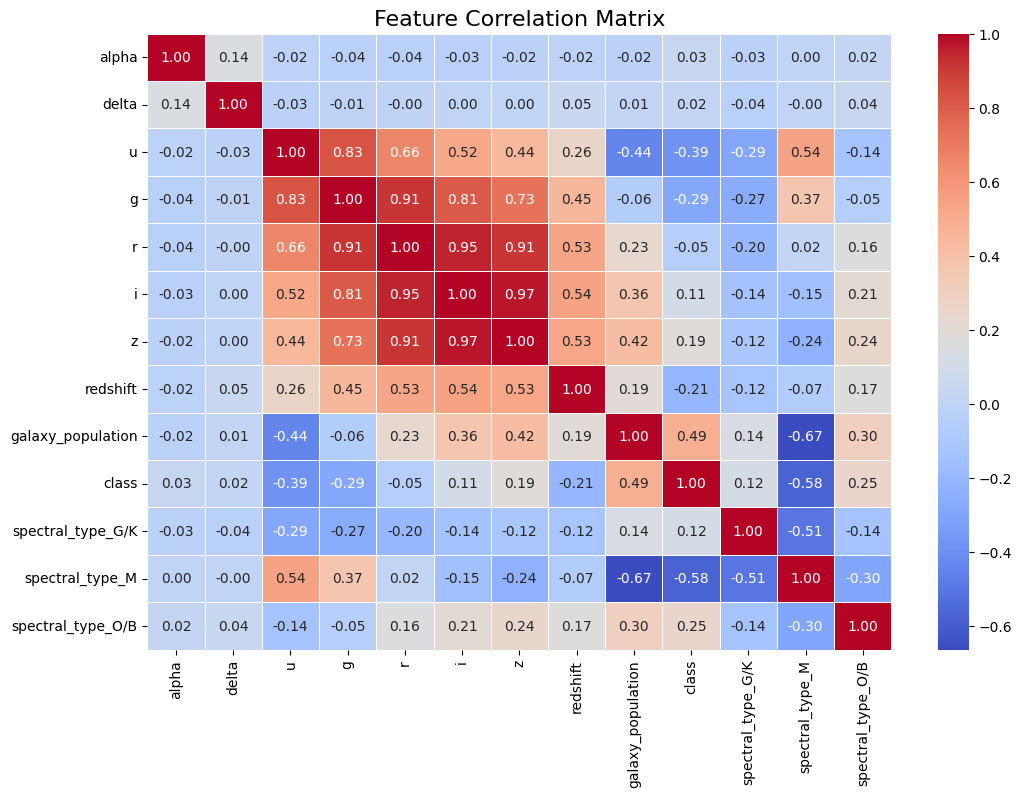


--- Correlation Matrix ---
                      alpha     delta         u         g         r         i         z  redshift  galaxy_population     class  spectral_type_G/K  spectral_type_M  spectral_type_O/B
alpha              1.000000  0.143541 -0.017242 -0.037731 -0.037830 -0.029333 -0.024583 -0.016293          -0.022856  0.033585          -0.026569         0.004330           0.021810
delta              0.143541  1.000000 -0.026860 -0.008386 -0.004395  0.002088  0.003347  0.049384           0.009908  0.017359          -0.039822        -0.001153           0.038214
u                 -0.017242 -0.026860  1.000000  0.826880  0.659410  0.521811  0.443923  0.259369          -0.439125 -0.385667          -0.288197         0.540288          -0.135480
g                 -0.037731 -0.008386  0.826880  1.000000  0.912066  0.805020  0.731737  0.448538          -0.061626 -0.285010          -0.265855         0.366362          -0.050296
r                 -0.037830 -0.004395  0.659410  0.912066  1.0

In [23]:
# 1. Feature Correlation Matrix
plt.figure(figsize=(12, 8))
correlation_matrix = preprocessed_numerical_train_df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Feature Correlation Matrix", fontsize=16)
plt.show()

# Print text output so the LLM can read the matrix
print("\n--- Correlation Matrix ---")
print(correlation_matrix.to_string())

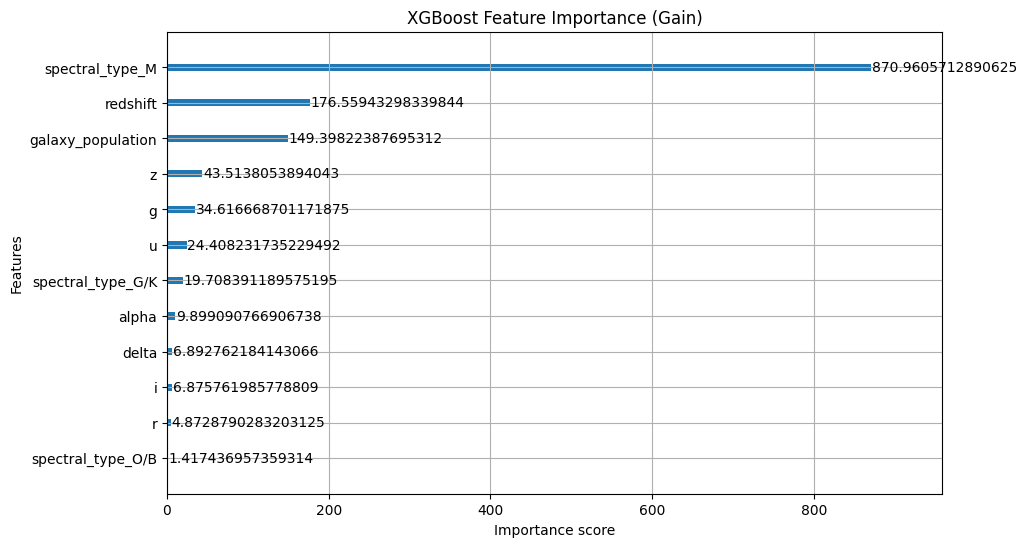


--- XGBoost Feature Importances (Gain) ---
spectral_type_M: 870.9606
redshift: 176.5594
galaxy_population: 149.3982
z: 43.5138
g: 34.6167
u: 24.4082
spectral_type_G/K: 19.7084
alpha: 9.8991
delta: 6.8928
i: 6.8758
r: 4.8729
spectral_type_O/B: 1.4174


In [24]:
# 2. XGBoost Feature Importance
from xgboost import plot_importance

# Retrieve our trained base XGBoost model
best_xgb = all_trained_models['base_XGBoost']

fig, ax = plt.subplots(figsize=(10, 6))
plot_importance(best_xgb, ax=ax, importance_type='gain', title="XGBoost Feature Importance (Gain)")
plt.show()

# Print text output so the LLM can read the feature importances
print("\n--- XGBoost Feature Importances (Gain) ---")
importances = best_xgb.get_booster().get_score(importance_type='gain')
for feature, gain in sorted(importances.items(), key=lambda x: x[1], reverse=True):
    print(f"{feature}: {gain:.4f}")

# Note: 'gain' represents the relative contribution of the feature to the model, 
# calculated by taking each feature's contribution for each tree in the model.

# 5.Submission

In [20]:
# 1. Prepare test data
test_X = test_df.copy()
test_X = test_X.drop(columns=['id'])

# Map 'galaxy_population' the same as train_df (Red_Sequence -> 0, Blue_Cloud -> 1)
test_X['galaxy_population'] = test_X['galaxy_population'].map({'Red_Sequence': 0, 'Blue_Cloud': 1})

# One-hot encode 'spectral_type'
test_X = pd.get_dummies(test_X, columns=['spectral_type'], drop_first=True, dtype=int)

# Align column order with training data and fill any missing dummy columns with 0
test_X = test_X.reindex(columns=X_train.columns, fill_value=0)

# Apply the exact same scalers fitted on our training data to the submission test data
test_X = transform_numerical_features(test_X, training_scalers)

# Determine the overall best model from both training runs
best_model_name = all_comparisons_df.iloc[0]['Model']
best_model = all_trained_models[best_model_name]
print(f"Selected '{best_model_name}' as the best model for submission.\n")

# 2. Make predictions and map numerical predictions back to string labels
reverse_class_mapping = {0: 'GALAXY', 1: 'QSO', 2: 'STAR'}
submission_df['class'] = pd.Series(best_model.predict(test_X)).map(reverse_class_mapping)

# 3. Save submission file
submission_df.to_csv('submission.csv', index=False)
print("Submission saved successfully!")
submission_df.head()

Selected 'base_XGBoost' as the best model for submission.

Submission saved successfully!


,id,class
0,577347,GALAXY
1,577348,GALAXY
2,577349,GALAXY
3,577350,STAR
4,577351,GALAXY
